# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: November 21, 2025

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

- Finding the mix of shoe design elements that enhances wearer comfort is the aim of this investigation. Examineing the effects of Sole Material, Insole Thickness, and Fabric Breathability on elite athletes' comfort ratings. Understanding whether these elements interact and to create the most comfortable running shoe model for their intended market by useing the statistical results to determine the ideal levels for each component.

2.  Specify the outcome variable and how it is measured.

**- Outcome Variable:** comfort

- It is assessed subjectively on a scale of 1 to 10, with 1 denoting "extremely unpleasant" and 10 denoting "very comfortable." Following a 30-minute run on a treadmill while wearing the designated shoe model, the data is gathered.

3.  Specify the independent variables. What lurking variables may be present?

- **IVs**: sole_material, insoul_thickness, and breathability

- Different lurking variable exist when it comes to what each athlete thinks about the shoes. This ranges from the types of socks that they are wearing, the environment during the run, the athlete's fatigue and recovory, etc.

4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

- Using a full factorial design, we can investigate every possible combination of all levels for each element. A complete factorial design would require $3 \times 4 \times 2 = 24$ distinct experimental runs if you had three factors: Factor A has three levels, Factor B has four levels, and Factor C has two levels. A $2^k$ Factorial Design is a particular, simplified form of a full factorial design in which each factor ($k$) is limited to precisely two levels. In this instance, $2^k$ is preferred because a $2^k$ design with three factors only needs $2^3 = 8$ distinct runs. Without evaluating every potential thickness or material variation, this enables the producer to rapidly determine which elements have the biggest impact on comfort. We can frequently presume a linear relationship between a factor and the result in the early phases of product development. The "slope" or direction of the effect can be ascertained by testing two levels.

5. State the sets of null and alternative hypotheses for this experiment.

**Main Effects**
- $H_0: \mu_{EVA} = \mu_{Gel}$ (Sole material has no effect on mean comfort.)
- $H_a: \mu_{EVA} \neq \mu_{Gel}$ (Sole material has a significant effect on mean comfort.)
- $H_0: \mu_{3mm} = \mu_{6mm}$ (Insole thickness has no effect on mean comfort.)
- $H_a: \mu_{3mm} \neq \mu_{6mm}$ (Insole thickness has a significant effect on mean comfort.)
- $H_0: \mu_{Woven} = \mu_{Mesh}$ (Fabric breathability has no effect on mean comfort.)
- $H_a: \mu_{Woven} \neq \mu_{Mesh}$ (Fabric breathability has a significant effect on mean comfort.)

**Two-Way Interactions**
- $H_0:$ There is no interaction between Sole Material and Insole Thickness.
- $H_a:$ There is a significant interaction between Sole Material and Insole Thickness.
- $H_0:$ There is no interaction between Sole Material and Fabric Breathability.
- $H_a:$ There is a significant interaction between Sole Material and Fabric Breathability.
- $H_0:$ There is no interaction between Insole Thickness and Fabric Breathability.
- $H_a:$ There is a significant interaction between Insole Thickness and Fabric Breathability.

**Three-Way Interactions**
- $H_0:$ There is no three-way interaction between the factors.
- $H_a:$ There is a significant three-way interaction between the factors.

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [2]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "cmuriithi"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW3"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/cmuriithi/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/cmuriithi/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW3


/tmp/ipykernel_6831/2701226635.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sole_material', y='comfort', data=shoe, palette='Set2')
/tmp/ipykernel_6831/2701226635.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='insole_thickness', y='comfort', data=shoe, palette='Set2')
/tmp/ipykernel_6831/2701226635.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='breathability', y='comfort', data=shoe, palette='Set2')
/tmp/ipykernel_6831/2701226635.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

                                                       sum_sq    df  \
C(sole_material)                                    22.814025   1.0   
C(insole_thickness)                                  9.439657   1.0   
C(breathability)                                     7.645101   1.0   
C(sole_material):C(insole_thickness)                 0.000485   1.0   
C(sole_material):C(breathability)                    0.700584   1.0   
C(insole_thickness):C(breathability)                 4.949082   1.0   
C(sole_material):C(insole_thickness):C(breathab...   0.641055   1.0   
Residual                                            15.630245  16.0   

                                                            F    PR(>F)  
C(sole_material)                                    23.353723  0.000184  
C(insole_thickness)                                  9.662965  0.006758  
C(breathability)                                     7.825956  0.012908  
C(sole_material):C(insole_thickness)                 0.000496  0

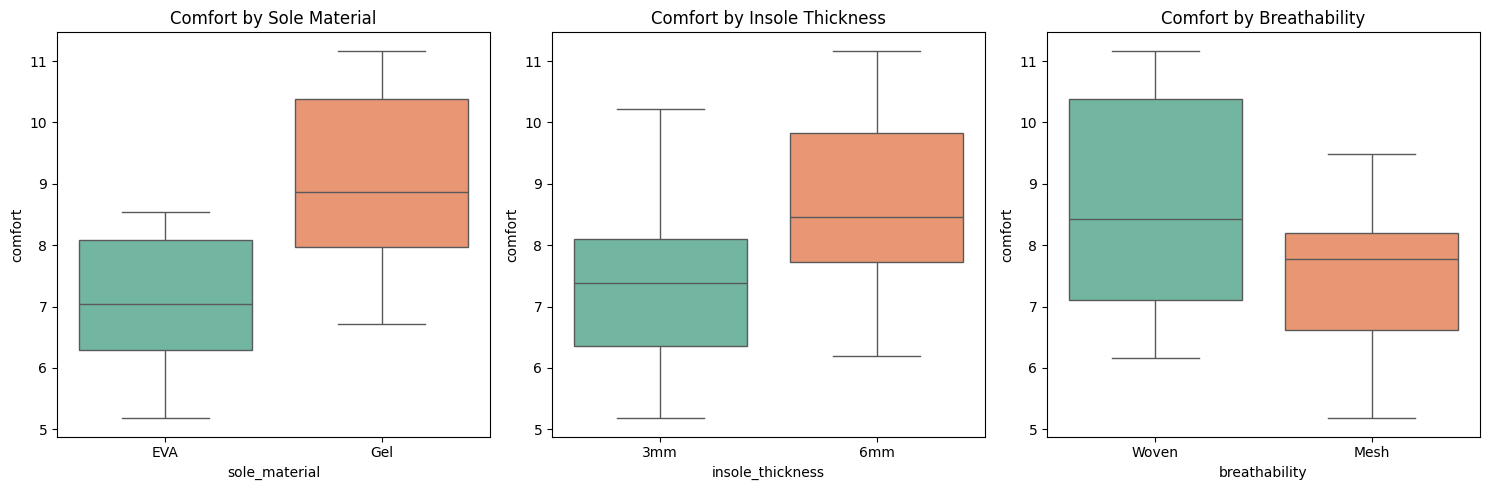

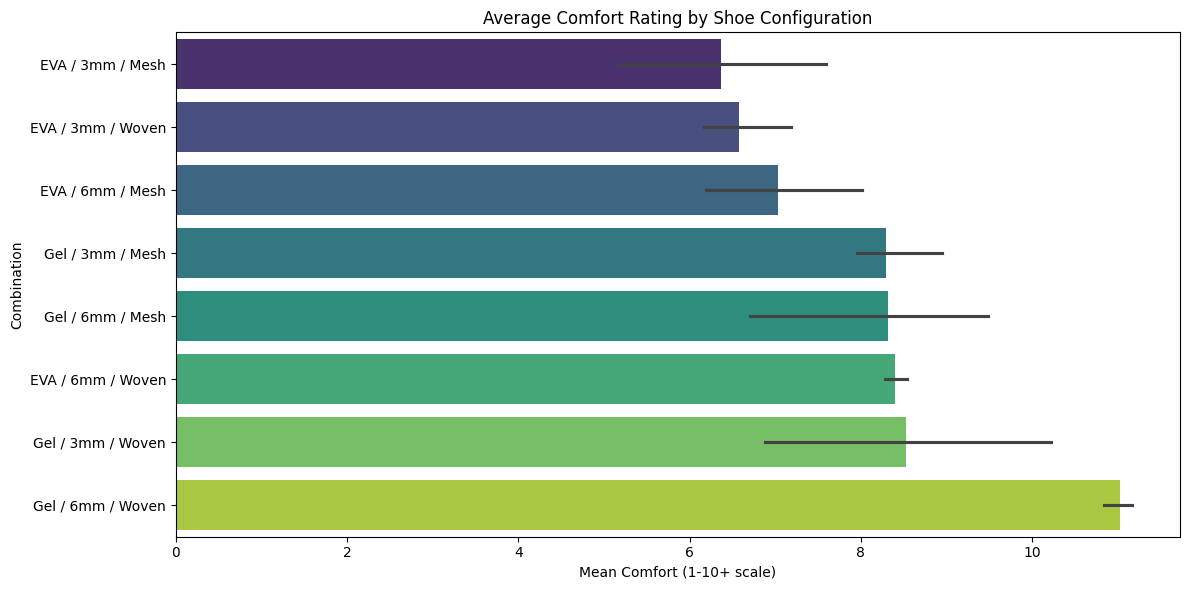

In [4]:
## Question 6 Code ##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load the shoe data
shoe = pd.read_excel('Shoe Comfort Experiment.xlsx', sheet_name='Sheet1')

# Summary Statistics
summary_stats = shoe.groupby(['sole_material', 'insole_thickness', 'breathability'])['comfort'].agg(['mean', 'std', 'count']).reset_index()
summary_stats.to_csv('summary_statistics.csv', index=False)

# Boxplots for Main Effects
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(x='sole_material', y='comfort', data=shoe, palette='Set2')
plt.title('Comfort by Sole Material')

plt.subplot(1, 3, 2)
sns.boxplot(x='insole_thickness', y='comfort', data=shoe, palette='Set2')
plt.title('Comfort by Insole Thickness')

plt.subplot(1, 3, 3)
sns.boxplot(x='breathability', y='comfort', data=shoe, palette='Set2')
plt.title('Comfort by Breathability')
plt.tight_layout()
plt.savefig('main_effects_boxplots.png')

# Bar chart for all 8 combinations
shoe['Combination'] = shoe['sole_material'] + " / " + shoe['insole_thickness'] + " / " + shoe['breathability']
plt.figure(figsize=(12, 6))
# Sort by mean comfort
order = shoe.groupby('Combination')['comfort'].mean().sort_values().index
sns.barplot(x='comfort', y='Combination', data=shoe, order=order, palette='viridis')
plt.title('Average Comfort Rating by Shoe Configuration')
plt.xlabel('Mean Comfort (1-10+ scale)')
plt.tight_layout()
plt.savefig('combination_comparison.png')

# ANOVA to analyize hypothesis testing
model = ols('comfort ~ C(sole_material) + C(insole_thickness) + C(breathability) + C(sole_material):C(insole_thickness) + C(sole_material):C(breathability) + C(insole_thickness):C(breathability) + C(sole_material):C(insole_thickness):C(breathability)', data=shoe).fit()
anova_results = sm.stats.anova_lm(model, typ=2)

print(anova_results)

- Each of the three primary elements (sole material, insole thickness, and fabric breathability) has a substantial effect on comfort. Furthermore, there is a substantial relationship between fabric breathability and insole thickness. There is no statistical significance for the remaining interactions to support the null hypothesis.

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?


Shapiro-Wilk Statistic: 0.959532741725587
Shapiro-Wilk P-value: 0.42910705030991836

ANOVA Table (Full Factorial):
                                                       sum_sq    df  \
C(sole_material)                                    22.814025   1.0   
C(insole_thickness)                                  9.439657   1.0   
C(breathability)                                     7.645101   1.0   
C(sole_material):C(insole_thickness)                 0.000485   1.0   
C(sole_material):C(breathability)                    0.700584   1.0   
C(insole_thickness):C(breathability)                 4.949082   1.0   
C(sole_material):C(insole_thickness):C(breathab...   0.641055   1.0   
Residual                                            15.630245  16.0   

                                                            F    PR(>F)  
C(sole_material)                                    23.353723  0.000184  
C(insole_thickness)                                  9.662965  0.006758  
C(breathability)       

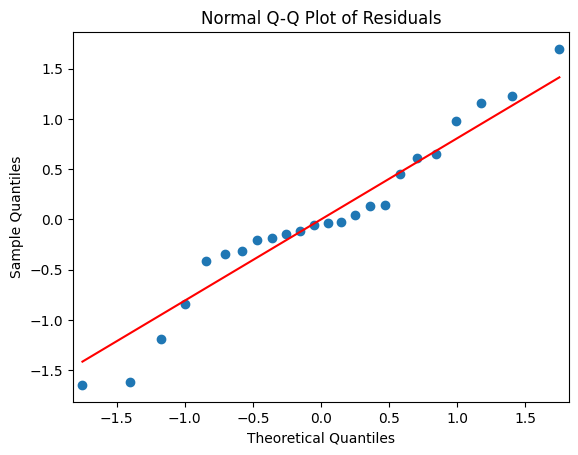

In [5]:
## Question 7 Code ##

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt

# Fit the full factorial model (all interactions)
shoe_model = ols('comfort ~ C(sole_material) * C(insole_thickness) * C(breathability)', data=shoe).fit()

# Extract residuals
residuals = shoe_model.resid

# Q-Q Plot
fig = sm.qqplot(residuals, line='s')
plt.title('Normal Q-Q Plot of Residuals')
plt.savefig('residual_qqplot.png')

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"Shapiro-Wilk Statistic: {shapiro_stat}")
print(f"Shapiro-Wilk P-value: {shapiro_p}")

# ANOVA summary
print("\nANOVA Table (Full Factorial):")
print(sm.stats.anova_lm(shoe_model, typ=2))

- There is enough evidence to back up the normalcy assumption. The Shapiro-Wilk test's p-value ($0.4291$) is significantly more than the conventional significance limit of $\alpha = 0.05$. As a result, the null hypothesis that the residuals are normally distributed cannot be rejected. Since the data points do not exhibit any notable snaking or heavy tails that would suggest a non-normal distribution, the Q-Q plot visually supports this conclusion. The results of the ANOVA can be regarded as legitimate and dependable for making design decisions because the normality assumption is met.


8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


Levene's Test Statistic: 1.0566842396160985
Levene's Test P-value: 0.43290523736236264


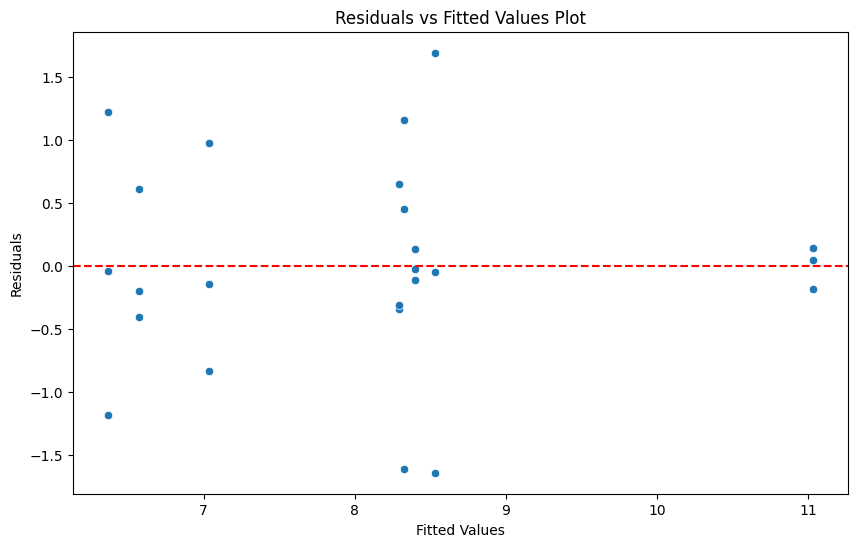

In [7]:
## Question 8 Code ##

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Residuals vs Fitted Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=shoe_model.fittedvalues, y=shoe_model.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values Plot')
plt.savefig('residuals_vs_fitted.png')

# Levene's Test (all factor combinations)
groups = shoe.groupby(['sole_material', 'insole_thickness', 'breathability'])['comfort'].apply(list).values
levene_stat, levene_p = stats.levene(*groups)

print(f"Levene's Test Statistic: {levene_stat}")
print(f"Levene's Test P-value: {levene_p}")

- There is enough data to back up the constant variance assumption. The Levene's test p-value ($0.4329$) is much higher than the $\alpha = 0.05$ significance level. This indicates that the null hypothesis of equal variances cannot be rejected. The statistical outcome is supported by the Residuals vs. Fitted plot, which displays a comparatively steady vertical distribution of residuals over the range of fitted comfort values. We can interpret the ANOVA results and the statistical significance of the shoe design components with confidence because both the normality and constant variance assumptions are satisfied.


9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?


In [10]:
## Question 9 Code ##

# The full factorial model (all interactions)
shoe_model = ols('comfort ~ C(sole_material) * C(insole_thickness) * C(breathability)', data=shoe).fit()

# ANOVA summary
print("\nANOVA Table (Full Factorial):")
print(sm.stats.anova_lm(shoe_model, typ=2))


ANOVA Table (Full Factorial):
                                                       sum_sq    df  \
C(sole_material)                                    22.814025   1.0   
C(insole_thickness)                                  9.439657   1.0   
C(breathability)                                     7.645101   1.0   
C(sole_material):C(insole_thickness)                 0.000485   1.0   
C(sole_material):C(breathability)                    0.700584   1.0   
C(insole_thickness):C(breathability)                 4.949082   1.0   
C(sole_material):C(insole_thickness):C(breathab...   0.641055   1.0   
Residual                                            15.630245  16.0   

                                                            F    PR(>F)  
C(sole_material)                                    23.353723  0.000184  
C(insole_thickness)                                  9.662965  0.006758  
C(breathability)                                     7.825956  0.012908  
C(sole_material):C(insole_thickne

**Main Effects**
- All three main factors are statistically significant ($p < 0.05$).
- **Sole Material:** This had the largest impact on comfort ($F = 23.35$). Athletes significantly preferred the Advanced gel-infused foam over the standard EVA foam.
- **Insole Thickness**: The 6mm insole provided significantly higher comfort than the 3mm insole.
- **Fabric Breathability:** The Standard woven fabric resulted in significantly higher comfort ratings than the high-performance mesh in this test environment.

**Two-Way Interactions**
- **Significant Interaction ($B \times C$):** Insole thickness and fabric breathability have a significant interaction ($p = 0.0388$). This implies that the type of cloth chosen determines how insole thickness affects comfort. In particular, the 6mm insole's comfort effect is significantly greater when the woven fabric is used as opposed to the mesh fabric.
- **Interactions that are not significant:** Sole Material and Thickness ($p = 0.9825$) and Sole Material and Breathability ($p = 0.4096$) did not significantly interact. This suggests that the benefit of the Gel sole material remains constant regardless of the fabric type or thickness selected.

**Three-Way Interaction**
- There is **no** statistically significant three-way interaction ($A \times B \times C$) ($p = 0.4298$). This implies that whether the sole is made of EVA or Gel has little effect on the two-way relationship between thickness and breathability. In contrast to their individual and two-way actions, the elements do not combine in a sophisticated three-way manner.


10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?


In [12]:
## Question 10 Code ##

# Generate the standard ANOVA table
anova_table = sm.stats.anova_lm(shoe_model, typ=2)

# Calculate Partial Eta Squared (ηp²)
# ηp² = SS_effect / (SS_effect + SS_error)
ss_error = anova_table.loc['Residual', 'sum_sq']
anova_table['partial_eta_sq'] = anova_table['sum_sq'] / (anova_table['sum_sq'] + ss_error)

# Display the final results (dropping the residual row)
final_results = anova_table.drop('Residual')[['sum_sq', 'df', 'F', 'PR(>F)', 'partial_eta_sq']]

print("ANOVA Results with Partial Eta Squared:")
print(final_results)

ANOVA Results with Partial Eta Squared:
                                                       sum_sq   df          F  \
C(sole_material)                                    22.814025  1.0  23.353723   
C(insole_thickness)                                  9.439657  1.0   9.662965   
C(breathability)                                     7.645101  1.0   7.825956   
C(sole_material):C(insole_thickness)                 0.000485  1.0   0.000496   
C(sole_material):C(breathability)                    0.700584  1.0   0.717157   
C(insole_thickness):C(breathability)                 4.949082  1.0   5.066160   
C(sole_material):C(insole_thickness):C(breathab...   0.641055  1.0   0.656220   

                                                      PR(>F)  partial_eta_sq  
C(sole_material)                                    0.000184        0.593431  
C(insole_thickness)                                 0.006758        0.376533  
C(breathability)                                    0.012908        0.3284

- The experiment's most crucial component is the **sole material** ($\eta_p^2 = 0.593$). About $59.3\%$ of the variation in comfort ratings can be explained by it. This implies that athletes' perceptions of the shoe are greatly influenced by the decision between conventional EVA foam and sophisticated gel-infused foam.
- **Fabric Breathability ($\eta_p^2 = 0.329$) and Insole Thickness ($\eta_p^2 = 0.377$):** These are also quite significant because they explain $32.9\%$ and $37.7\%$ of the variance, in that order. They are important for optimization even though they are not as important as the single substance.
- **Thickness $\times$ Interaction between breathability ($\eta_p^2 = 0.240$):** The most important interaction is this one. $24\%$ of the variance is explained by it. This indicates that the maker cannot just choose the "best" thickness and "best" cloth on their own; the connection between the two is a significant part of the overall comfort experience.


11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?

- Sole Material is the most critical factor. The Advanced Gel-infused foam resulted in a massive increase in comfort ratings compared to EVA foam, explaining nearly 60% of the variance in the data. All three factors (Sole Material, Insole Thickness, and Fabric Breathability) showed statistically significant main effects ($p < 0.05$).

- There is a significant interaction between Insole Thickness and Breathability. This means that the comfort level is not just about picking the best thickness and fabric individually, but how they work together. The 6mm insole performs exceptionally well when paired with the Woven fabric.

- The conclusions are highly reliable as the model passed both the Normality (Shapiro-Wilk) and Constant Variance (Levene’s) tests, ensuring the statistical assumptions were not violated.

**Final Recommendation:**
- **Sole Material:** Advanced gel-infused foam
- **Insole Thickness:** 6mm
- **Fabric Breathability:** Standard woven fabric

The analysis showed that while 6mm and Woven were better individually, they are particularly effective when combined. The interaction effect indicates that the Woven fabric maximizes the perceived comfort benefit of the thicker insole to go aling with the high rating of the gel-infused foam (look back at question 6).


## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

- Given the time and resource constraints of recruiting NCAA athletes for month-long tests, it is crucial to screen the main impacts of three separate factors using only 4 experimental runs. To maximize athlete happiness, choose the best feature combination and determine whether the fitness band's perceived value is more influenced by user interface features or technical features.

2.  Specify the outcome variable and how it is measured.

- **Outcome Variable:** Satisfaction
1-10 scale and collecting by ratings from 3 NCAA Division I cross-country athletes for each experimental run. These athletes use their assigned fitness band for a full month during their competition season before providing their final satisfaction rating.

3.  Specify the independent variables. What lurking variables may be present?

- **IVs:** GPS_Accuracy, Battery_Life, and Display

- There could be a number of hidden factors in this one-month field study including athletes that can be lurking variablessuch as their training intensity, software glitches, environmental conditions, etc.

4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

- The number of experimental runs carried out and the ensuing capacity to differentiate between various effects are the main distinctions between a full factorial design and a fractional factorial design. NCAA Division I athletes are recruited throughout the entire month of their competitive season as part of the experiment. It would take twice as many athletes or a lot more time to test eight different band configurations (full factorial) than it would to evaluate four configurations. Tracking usage statistics over a 30-day period makes managing 12 athletes (3 per run for 4 runs) more simpler than managing 24 athletes over 8 different settings, making a $2^{3-1}$ more reasonable.

5.  State the sets of null and alternative hypotheses for this experiment.

**Hypotheses for GPS_Accuracy**
- Null Hypothesis ($H_{0, A}$): GPS Accuracy has no effect on user satisfaction. The mean satisfaction score for "Standard" accuracy is equal to the mean satisfaction score for "High" accuracy. ($\mu_{Standard} = \mu_{High}$)
- Alternative Hypothesis ($H_{a, A}$): GPS Accuracy has a significant effect on user satisfaction. The mean satisfaction scores are not equal. ($\mu_{Standard} \neq \mu_{High}$)

**Hypotheses for Battery_Life (Factor B)**
- Null Hypothesis ($H_{0, B}$): Battery Life has no effect on user satisfaction. The mean satisfaction score for "6 Hours" is equal to the mean satisfaction score for "12 Hours." ($\mu_{6hr} = \mu_{12hr}$)
- Alternative Hypothesis ($H_{a, B}$): Battery Life has a significant effect on user satisfaction. The mean satisfaction scores are not equal. ($\mu_{6hr} \neq \mu_{12hr}$)

**Hypotheses for Display Size (Factor C)**
- Null Hypothesis ($H_{0, C}$): Display Size has no effect on user satisfaction. The mean satisfaction score for "Small" displays is equal to the mean satisfaction score for "Large" displays. ($\mu_{Small} = \mu_{Large}$)
- Alternative Hypothesis ($H_{a, C}$): Display Size has a significant effect on user satisfaction. The mean satisfaction scores are not equal. ($\mu_{Small} \neq \mu_{Large}$)


6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

- In a fractional design, we find aliases by multiplying the effect of interest by the defining relation ($I$). Since any factor squared equals identity ($A^2 = I$), the structure is:$A = BC$: The main effect of GPS Accuracy is aliased with the interaction of Battery Life and Display.$B = AC$: The main effect of Battery Life is aliased with the interaction of GPS Accuracy and Display.$C = AB$: The main effect of Display is aliased with the interaction of GPS Accuracy and Battery Life.

7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [ ]:
## Question 7 Code ##


8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


In [ ]:
## Question 8 Code ##


9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


In [ ]:
## Question 9 Code ##

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

In [ ]:
## Question 12 Code ##

13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?